# Temporal Analysis of Users according to their ideology and credibility (40 messages threshold).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import datasets
df = pd.read_json("../../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

In [3]:
df_users.head()

,sender_id,ideology_score,credibility_score
0,1110241832,0,-1
1,5919794964,0,0
2,1093591792,0,0
3,1622328415,0,0
4,6618601093,0,0


## Ideology_score division

In [4]:
# Divide users into three groups based on their ideology score: neutral, right-wing, and left-wing.
neutral_users = df_users[df_users['ideology_score'] == 0] # Gather users with a neutral ideology score (0).
right_users = df_users[df_users['ideology_score'] > 0] # Gather users with a right-wing ideology score.
left_users = df_users[df_users['ideology_score'] < 0] # Gather users with a left-wing ideology score.

In [5]:
neutral_users.size, right_users.size, left_users.size


(1221, 105, 15)

In [6]:
neutral_users_id = neutral_users['sender_id'].tolist() # Get the sender IDs of neutral users.
right_users_id = right_users['sender_id'].tolist() # Get the sender IDs of right-wing users.
left_users_id = left_users['sender_id'].tolist() # Get the sender IDs of left-wing users.

In [7]:
# Gather messages sent by neutral users, right-wing users, and left-wing users.
neutral_messages = df[df['sender_id'].isin(neutral_users_id)] # Gather messages sent by neutral users.
right_messages = df[df['sender_id'].isin(right_users_id)] # Gather messages sent by right-wing users.
left_messages = df[df['sender_id'].isin(left_users_id)] # Gather messages sent by left-wing users.

neutral_messages.size, right_messages.size, left_messages.size

(118660, 46155, 9486)

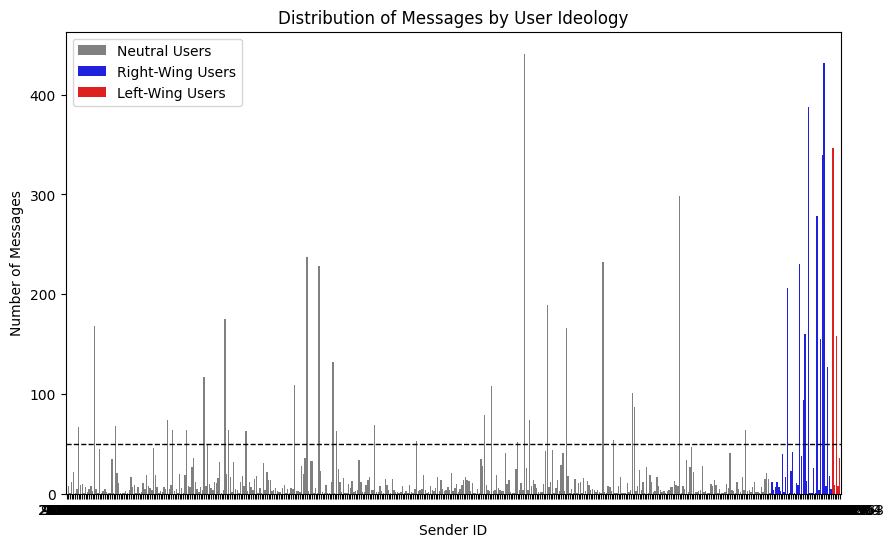

In [8]:
# Plot the distribution of messages sent by neutral users, right-wing users, and left-wing users.
plt.figure(figsize=(10, 6))
sns.countplot(x='sender_id', data=neutral_messages, color='gray', label='Neutral Users')
sns.countplot(x='sender_id', data=right_messages, color='blue', label='Right-Wing Users')
sns.countplot(x='sender_id', data=left_messages, color='red', label='Left-Wing Users')
plt.axhline(y=50, color='black', linestyle='--', linewidth=1) # Add a horizontal line at y=50 for better visualization of the distribution of the cutoff.
plt.xlabel('Sender ID')
plt.xlabel('Sender ID')
plt.ylabel('Number of Messages')
plt.title('Distribution of Messages by User Ideology')
plt.legend()
plt.show()

In [9]:
# gather users with 40 or more messages sent for each ideology group
neutral_active_users = neutral_messages['sender_id'].value_counts()[neutral_messages['sender_id'].value_counts() >= 40].index.tolist() # Gather sender IDs of neutral users with 40 or more messages sent.
right_active_users = right_messages['sender_id'].value_counts()[right_messages['sender_id'].value_counts() >= 40].index.tolist() # Gather sender IDs of right-wing users with 40 or more messages sent.
left_active_users = left_messages['sender_id'].value_counts()[left_messages['sender_id'].value_counts() >= 40].index.tolist() # Gather sender IDs of left-wing users with 40 or more messages sent.
len(neutral_active_users), len(right_active_users), len(left_active_users)


(39, 12, 2)

In [10]:
# from these active users, get their period of activity and number of messages sent

def print_active_users_summary(group_name, active_users, messages_df):
    print("=" * 70)
    print(f"{group_name} Active Users:\n")
    print("=" * 70)
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        period_of_activity = user_dates.max() - user_dates.min() # Calculate the period of activity of the user.
        number_of_messages = user_messages.shape[0] # Calculate the number of messages sent by the user.
        print(f"User {user} has a period of activity of {period_of_activity} and has sent {number_of_messages} messages.")

print_active_users_summary("Neutral", neutral_active_users, neutral_messages)
print_active_users_summary("Right", right_active_users, right_messages)
print_active_users_summary("Left", left_active_users, left_messages)


Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 6601816159 has a period of activity of 40 days 08:34:08 and has sent 298 messages.
User 1095473116 has a period of activity of 7 days 12:38:49 and has sent 237 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 1110241832 has a period of activity of 375 days 22:27:23 and has sent 228 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 791270353 has a period of activity of 56 days 17:01:07 and has sent 175 messages.
User 57072401 has a period of activity of 25 days 02:03:04 and has sent 168 messages.
User 5212333848 has a period of activity of 6 days 04:21:20 and has sent 166 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 693274644 has a period of activity of 9 days 18:07:40 and has sent 117 messages.
User 10653321

In [11]:
# Remove users with a period of activity of less than 5 days

def filter_users_by_activity(active_users, messages_df, min_days=5):
    kept_users = []
    min_period = pd.Timedelta(days=min_days)
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        if user_dates.empty:
            continue
        period_of_activity = user_dates.max() - user_dates.min() # Calculate the period of activity of the user.
        if period_of_activity >= min_period:
            kept_users.append(user)
    return kept_users

neutral_active_users = filter_users_by_activity(neutral_active_users, neutral_messages, min_days=5)
right_active_users = filter_users_by_activity(right_active_users, right_messages, min_days=5)
left_active_users = filter_users_by_activity(left_active_users, left_messages, min_days=5)

len(neutral_active_users), len(right_active_users), len(left_active_users)

(32, 9, 2)

In [12]:
# from these filtered active users, get their period of activity and number of messages sent
print_active_users_summary("Neutral", neutral_active_users, neutral_messages)
print_active_users_summary("Right", right_active_users, right_messages)
print_active_users_summary("Left", left_active_users, left_messages)


Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 6601816159 has a period of activity of 40 days 08:34:08 and has sent 298 messages.
User 1095473116 has a period of activity of 7 days 12:38:49 and has sent 237 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 1110241832 has a period of activity of 375 days 22:27:23 and has sent 228 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 791270353 has a period of activity of 56 days 17:01:07 and has sent 175 messages.
User 57072401 has a period of activity of 25 days 02:03:04 and has sent 168 messages.
User 5212333848 has a period of activity of 6 days 04:21:20 and has sent 166 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 693274644 has a period of activity of 9 days 18:07:40 and has sent 117 messages.
User 10653321

### Waiting times for neutral users

In [13]:
# Plain power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail
import powerlaw
from scipy import stats

def fit_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        if show_results:
            print("=" * 70)
            print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
            print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        _, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    if show_results:
        print("=" * 70)
        print(f"POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_pl:.4f}")
        print(f"xmin: {xmin_pl:.4f}")
        print(f"sigma: {sigma_pl:.4f}")
        n_tail_pl = int(np.sum(data_pl >= xmin_pl))
        print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
            ("power_law", "lognormal", "Power Law vs Lognormal"),
            ("power_law", "exponential", "Power Law vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print("  Power law is significantly better")
                else:
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:
                print("  No significant difference")

        print("\n" + "=" * 70)
        print(f"KS distance (power law): {ks_pl:.4f}")
        print(f"KS p-value (tail): {ks_p_pl:.6g}")
        print("=" * 70)

    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
        fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
        fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return fit_pl

In [14]:
# Truncated power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail
def fit_truncated_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    tpl = fit_pl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "lambda_", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)
    if show_results:
        print("=" * 70)
        print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_tpl:.4f}")
        print(f"lambda: {lambda_tpl:.4f}")
        print(f"xmin: {xmin_tpl:.4f}")
        print(f"sigma: {sigma_tpl:.4f}")
        n_tail_tpl = int(np.sum(data_pl >= xmin_tpl))
        print(f"Data points above xmin: {n_tail_tpl} / {len(data_pl)} ({100 * n_tail_tpl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("TRUNCATED POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
            ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
            ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print(f"  Truncated power law is significantly better")
                else:                
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:            
                print("  No significant difference")
        tail_tpl = np.sort(data_pl[data_pl >= xmin_tpl])
        if len(tail_tpl) == 0:
            ks_tpl = float("nan")
            ks_p_tpl = float("nan")
        else:
            empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
            try:
                model_cdf_tpl = tpl.cdf(tail_tpl)
            except Exception:
                model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
            ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
            ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
        
        print("\n" + "=" * 70)
        print(f"KS distance (truncated power law): {ks_tpl:.4f}")
        print(f"KS p-value (tail): {ks_p_tpl:.6g}")
        print("=" * 70)
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        tpl.plot_pdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[0])
        fit_pl.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Truncated Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        tpl.plot_ccdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[1])
        fit_pl.power_law.plot_ccdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Truncated Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    return fit_pl


### Waiting times for right-wing users

### Waiting times for left-wing users

### Comparison of alpha for the different users

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

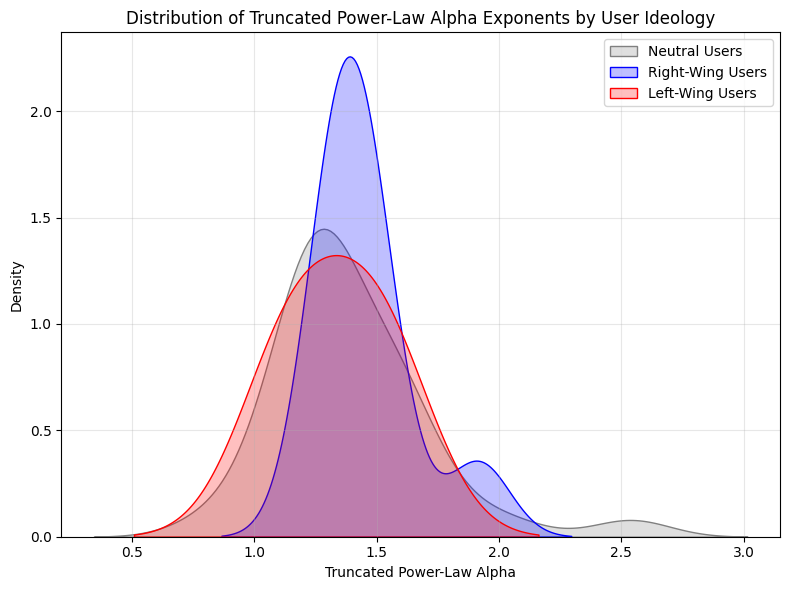

In [15]:
# Compare the truncated power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_truncated_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.truncated_power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
neutral_alphas, neutral_lambdas = extract_truncated_power_law_params(neutral_active_users, neutral_messages)
right_alphas, right_lambdas = extract_truncated_power_law_params(right_active_users, right_messages)
left_alphas, left_lambdas = extract_truncated_power_law_params(left_active_users, left_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(right_alphas, color='blue', label='Right-Wing Users', fill=True)
sns.kdeplot(left_alphas, color='red', label='Left-Wing Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents by User Ideology')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

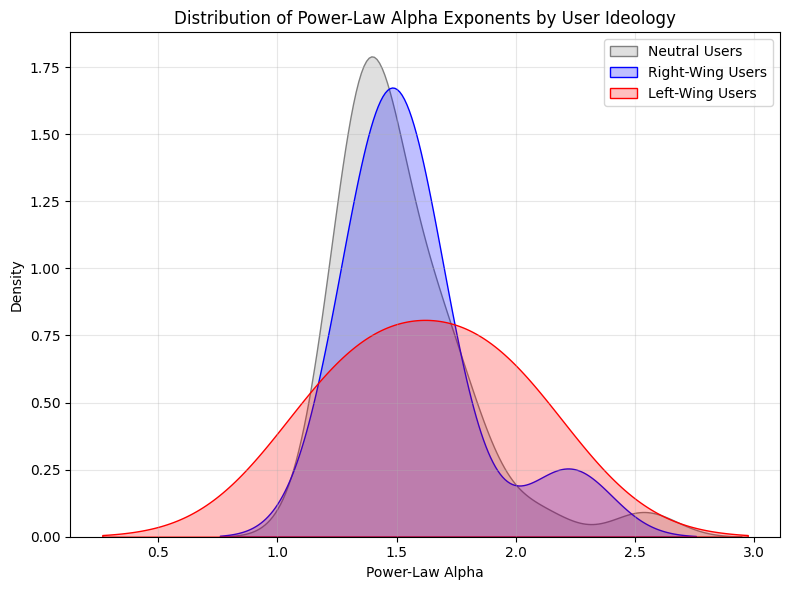

In [16]:
# Compare the normal power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
neutral_alphas, neutral_lambdas = extract_power_law_params(neutral_active_users, neutral_messages)
right_alphas, right_lambdas = extract_power_law_params(right_active_users, right_messages)
left_alphas, left_lambdas = extract_power_law_params(left_active_users, left_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(right_alphas, color='blue', label='Right-Wing Users', fill=True)
sns.kdeplot(left_alphas, color='red', label='Left-Wing Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents by User Ideology')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Credibility_score division

In [17]:
# Divide users into three groups based on their credibility score: credible (<0), neutral (0), and non-credible (>0).
credible_users = df_users[df_users['credibility_score'] < 0] # Gather users with a credible credibility score (<0).
neutral_credibility_users = df_users[df_users['credibility_score'] == 0] # Gather users with a neutral credibility score (0).
non_credible_users = df_users[df_users['credibility_score'] > 0] # Gather users with a non-credible credibility score (>0).


In [18]:
neutral_credibility_users.size, non_credible_users.size, credible_users.size

(1188, 108, 45)

In [19]:
neutral_credibility_users_id = neutral_credibility_users['sender_id'].tolist() # Get the sender IDs of neutral users.
credible_users_id = credible_users['sender_id'].tolist() # Get the sender IDs of credible users.
non_credible_users_id = non_credible_users['sender_id'].tolist() # Get the sender IDs of non-credible users.

In [20]:
# Gather messages sent by neutral users, credible users, and non-credible users.
neutral_credibility_messages = df[df['sender_id'].isin(neutral_credibility_users_id)] # Gather messages sent by neutral users.
credible_messages = df[df['sender_id'].isin(credible_users_id)] # Gather messages sent by credible users.
non_credible_messages = df[df['sender_id'].isin(non_credible_users_id)] # Gather messages sent by non-credible users.

neutral_credibility_messages.size, credible_messages.size, non_credible_messages.size

(102493, 34272, 37536)

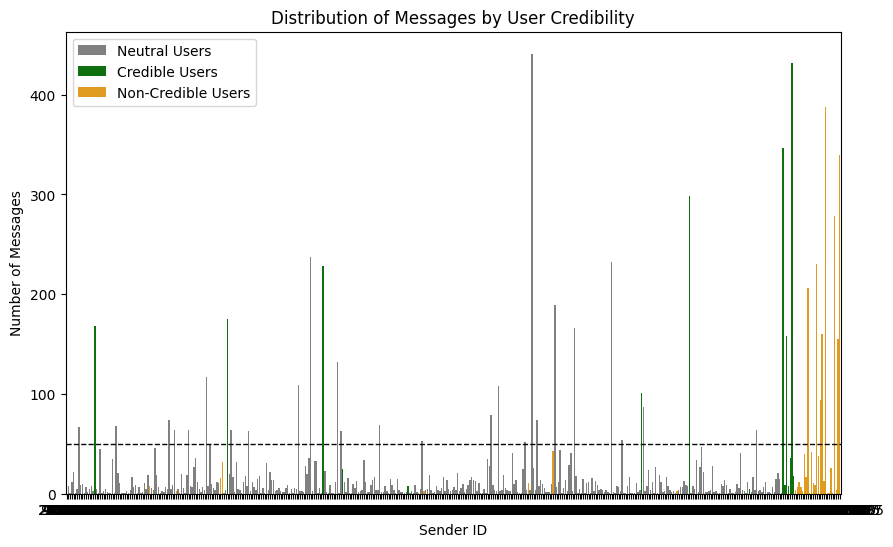

In [21]:
# Plot the distribution of messages sent by neutral users, credible users, and non-credible users.
plt.figure(figsize=(10, 6))
sns.countplot(x='sender_id', data=neutral_messages, color='gray', label='Neutral Users')
sns.countplot(x='sender_id', data=credible_messages, color='green', label='Credible Users')
sns.countplot(x='sender_id', data=non_credible_messages, color='orange', label='Non-Credible Users')
plt.axhline(y=50, color='black', linestyle='--', linewidth=1) # Add a horizontal line at y=50 for better visualization of the distribution of the cutoff.
plt.xlabel('Sender ID')
plt.ylabel('Number of Messages')
plt.title('Distribution of Messages by User Credibility')
plt.legend()
plt.show()

In [22]:
# gather users with 40 or more messages sent for each credibility group
neutral_credibility_active_users = neutral_credibility_messages['sender_id'].value_counts()[neutral_credibility_messages['sender_id'].value_counts() >= 40].index.tolist() # Gather sender IDs of neutral users with 40 or more messages sent.
credible_active_users = credible_messages['sender_id'].value_counts()[credible_messages['sender_id'].value_counts() >= 40].index.tolist() # Gather sender IDs of credible users with 40 or more messages sent.
non_credible_active_users = non_credible_messages['sender_id'].value_counts()[non_credible_messages['sender_id'].value_counts() >= 40].index.tolist() # Gather sender IDs of non-credible users with 40 or more messages sent.
len(neutral_credibility_active_users), len(credible_active_users), len(non_credible_active_users)


(34, 8, 11)

In [23]:
# from these active users, get their period of activity and number of messages sent

print_active_users_summary("Neutral", neutral_credibility_active_users, neutral_credibility_messages)
print_active_users_summary("Credible", credible_active_users, credible_messages)
print_active_users_summary("Non-Credible", non_credible_active_users, non_credible_messages)

Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 1095473116 has a period of activity of 7 days 12:38:49 and has sent 237 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 5212333848 has a period of activity of 6 days 04:21:20 and has sent 166 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 7567764882 has a period of activity of 10 days 13:51:55 and has sent 127 messages.
User 693274644 has a period of activity of 9 days 18:07:40 and has sent 117 messages.
User 1065332141 has a period of activity of 6 days 10:28:52 and has sent 109 messages.
User 1551829597 has a period of activity of 213 days 00:44:52 and has sent 108 messages.
User 6019632868 has a period of activity of 3 days 09:35:42 and has sent 87 messages.
User 15274886

In [24]:
# Remove users with a period of activity of less than 5 days


neutral_credibility_active_users = filter_users_by_activity(neutral_credibility_active_users, neutral_credibility_messages, min_days=5)
credible_active_users = filter_users_by_activity(credible_active_users, credible_messages, min_days=5)
non_credible_active_users = filter_users_by_activity(non_credible_active_users, non_credible_messages, min_days=5)

len(neutral_credibility_active_users), len(credible_active_users), len(non_credible_active_users)

(27, 8, 8)

In [25]:
# from these active users, get their period of activity and number of messages sent

print_active_users_summary("Neutral", neutral_credibility_active_users, neutral_credibility_messages)
print_active_users_summary("Credible", credible_active_users, credible_messages)
print_active_users_summary("Non-Credible", non_credible_active_users, non_credible_messages)

Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 1095473116 has a period of activity of 7 days 12:38:49 and has sent 237 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 5212333848 has a period of activity of 6 days 04:21:20 and has sent 166 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 7567764882 has a period of activity of 10 days 13:51:55 and has sent 127 messages.
User 693274644 has a period of activity of 9 days 18:07:40 and has sent 117 messages.
User 1065332141 has a period of activity of 6 days 10:28:52 and has sent 109 messages.
User 1551829597 has a period of activity of 213 days 00:44:52 and has sent 108 messages.
User 1527488629 has a period of activity of 27 days 06:04:46 and has sent 79 messages.
User 4386012

### Waiting times for neutral users

### Credible users

### Non-credible users

### Comparison of alpha for the different users

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

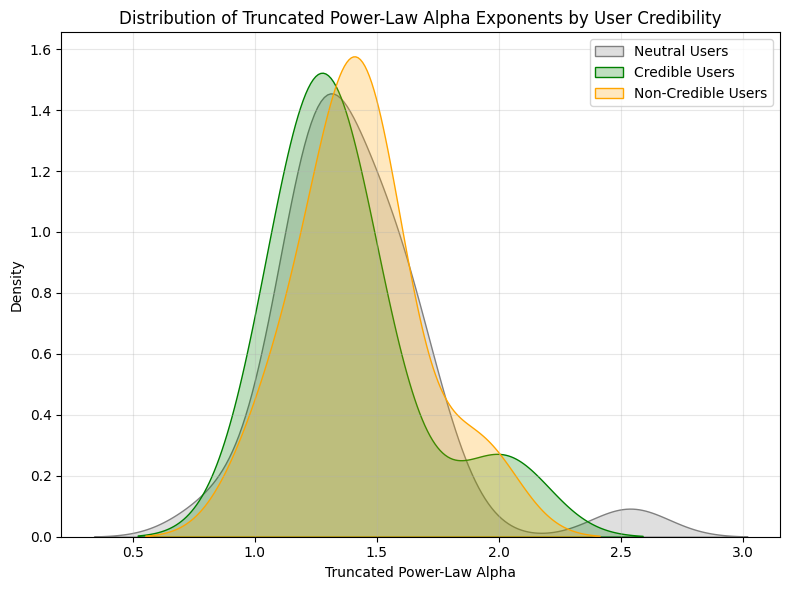

In [26]:
neutral_credibility_alphas, neutral_credibility_lambdas = extract_truncated_power_law_params(neutral_credibility_active_users, neutral_credibility_messages)
credible_alphas, credible_lambdas = extract_truncated_power_law_params(credible_active_users, credible_messages)
non_credible_alphas, non_credible_lambdas = extract_truncated_power_law_params(non_credible_active_users, non_credible_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_credibility_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(credible_alphas, color='green', label='Credible Users', fill=True)
sns.kdeplot(non_credible_alphas, color='orange', label='Non-Credible Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents by User Credibility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

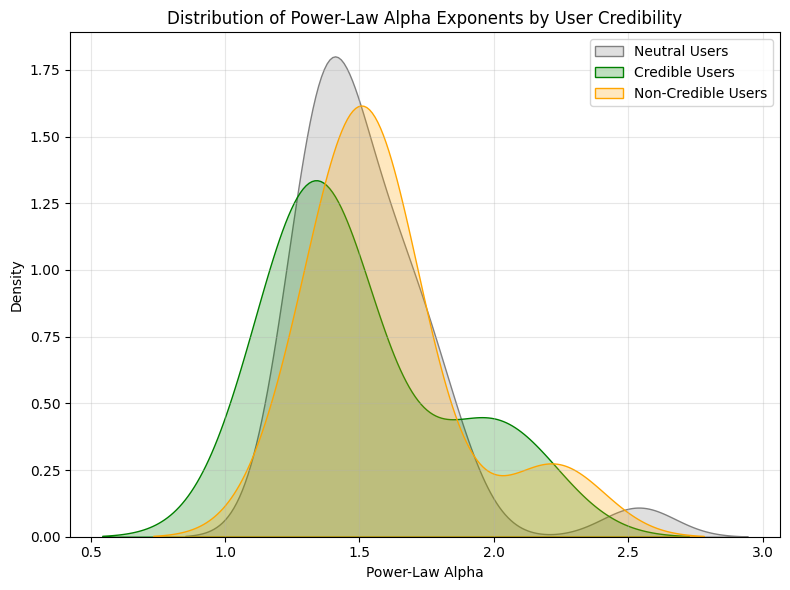

In [27]:
neutral_credibility_alphas, neutral_credibility_lambdas = extract_power_law_params(neutral_credibility_active_users, neutral_credibility_messages)
credible_alphas, credible_lambdas = extract_power_law_params(credible_active_users, credible_messages)
non_credible_alphas, non_credible_lambdas = extract_power_law_params(non_credible_active_users, non_credible_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_credibility_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(credible_alphas, color='green', label='Credible Users', fill=True)
sns.kdeplot(non_credible_alphas, color='orange', label='Non-Credible Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents by User Credibility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## KM-corrected TPL alpha (full community lifespan)

In [28]:
from lifelines import KaplanMeierFitter
from scipy.optimize import curve_fit
import powerlaw

# Cutoff = last message in the dataset (full community lifespan, no artificial Jan 1st cutoff)
cutoff_date = df['date'].max()


def extract_tpl_params_km(users, messages_df, cutoff):
    """Fit a TPL to each user's KM-corrected survival curve, returning per-user alpha."""
    alphas_tpl_km = []
    for user in users:
        user_msgs  = messages_df[messages_df['sender_id'] == user]
        user_dates = pd.to_datetime(user_msgs['date'], errors='coerce').dropna().sort_values()
        if len(user_dates) < 10:
            continue
        waiting = user_dates.diff().dt.total_seconds().dropna()
        waiting = waiting[(waiting > 0) & np.isfinite(waiting)].values
        if len(waiting) < 10:
            continue

        # Censored observation: time from last message to end of dataset
        tau_fc = max((cutoff - user_dates.iloc[-1]).total_seconds(), 0.0)
        km_dur = np.concatenate([waiting, waiting, [tau_fc]])
        km_obs = np.concatenate([np.ones(len(waiting)), np.ones(len(waiting)), [0]])
        kmf = KaplanMeierFitter()
        kmf.fit(km_dur, event_observed=km_obs.astype(bool))

        fit     = powerlaw.Fit(waiting, discrete=True, verbose=False)
        xmin    = float(getattr(fit.truncated_power_law, 'xmin',  np.nan))
        alpha_r = float(getattr(fit.truncated_power_law, 'alpha', np.nan))

        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask_tail = (km_t >= xmin) & (km_s > 0)
        if not np.isfinite(xmin) or mask_tail.sum() < 5:
            continue

        km_t_tail = km_t[mask_tail]
        s_at_xmin = float(np.interp(xmin, km_t, km_s))
        if s_at_xmin <= 0:
            continue
        km_s_norm = km_s[mask_tail] / s_at_xmin

        def tpl_surv(t, alpha, lam):
            return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)
        try:
            popt, _ = curve_fit(
                tpl_surv, km_t_tail, km_s_norm,
                p0=[max(alpha_r, 1.01), 1.0 / waiting.max()],
                bounds=([1.001, 0.0], [20.0, np.inf]), maxfev=10000
            )
            alphas_tpl_km.append(float(popt[0]))
        except Exception:
            continue
    return alphas_tpl_km


# ── Ideology groups ───────────────────────────────────────────────────────────
print("Running KM-corrected TPL fit — ideology groups ...")
alphas_neutral_km   = extract_tpl_params_km(neutral_active_users,  neutral_messages,  cutoff_date)
alphas_right_km     = extract_tpl_params_km(right_active_users,    right_messages,    cutoff_date)
alphas_left_km      = extract_tpl_params_km(left_active_users,     left_messages,     cutoff_date)

print(f"  Neutral : {len(alphas_neutral_km)} users,  mean α = {np.mean(alphas_neutral_km):.3f}")
print(f"  Right   : {len(alphas_right_km)} users,  mean α = {np.mean(alphas_right_km):.3f}")
print(f"  Left    : {len(alphas_left_km)} users,  mean α = {np.mean(alphas_left_km):.3f}")

# ── Credibility groups ────────────────────────────────────────────────────────
print("\nRunning KM-corrected TPL fit — credibility groups ...")
alphas_neutral_cred_km  = extract_tpl_params_km(neutral_credibility_active_users, neutral_credibility_messages, cutoff_date)
alphas_credible_km      = extract_tpl_params_km(credible_active_users,            credible_messages,            cutoff_date)
alphas_non_credible_km  = extract_tpl_params_km(non_credible_active_users,        non_credible_messages,        cutoff_date)

print(f"  Neutral (cred.)  : {len(alphas_neutral_cred_km)} users,  mean α = {np.mean(alphas_neutral_cred_km):.3f}")
print(f"  Credible         : {len(alphas_credible_km)} users,  mean α = {np.mean(alphas_credible_km):.3f}")
print(f"  Non-credible     : {len(alphas_non_credible_km)} users,  mean α = {np.mean(alphas_non_credible_km):.3f}")


Running KM-corrected TPL fit — ideology groups ...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  Neutral : 32 users,  mean α = 1.490
  Right   : 9 users,  mean α = 1.527
  Left    : 2 users,  mean α = 1.502

Running KM-corrected TPL fit — credibility groups ...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  Neutral (cred.)  : 27 users,  mean α = 1.505
  Credible         : 8 users,  mean α = 1.445
  Non-credible     : 8 users,  mean α = 1.531


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Ideology — Kruskal-Wallis: H=1.170, p=0.5571
  Neutral vs Right  : D=0.420, p=0.1204
  Neutral vs Left   : D=0.406, p=0.8556
  Right vs Left     : D=0.500, p=0.7091

Credibility — Kruskal-Wallis: H=1.135, p=0.5669
  Neutral vs Credible      : D=0.306, p=0.5039
  Neutral vs Non-credible  : D=0.255, p=0.7269
  Credible vs Non-credible : D=0.500, p=0.2827


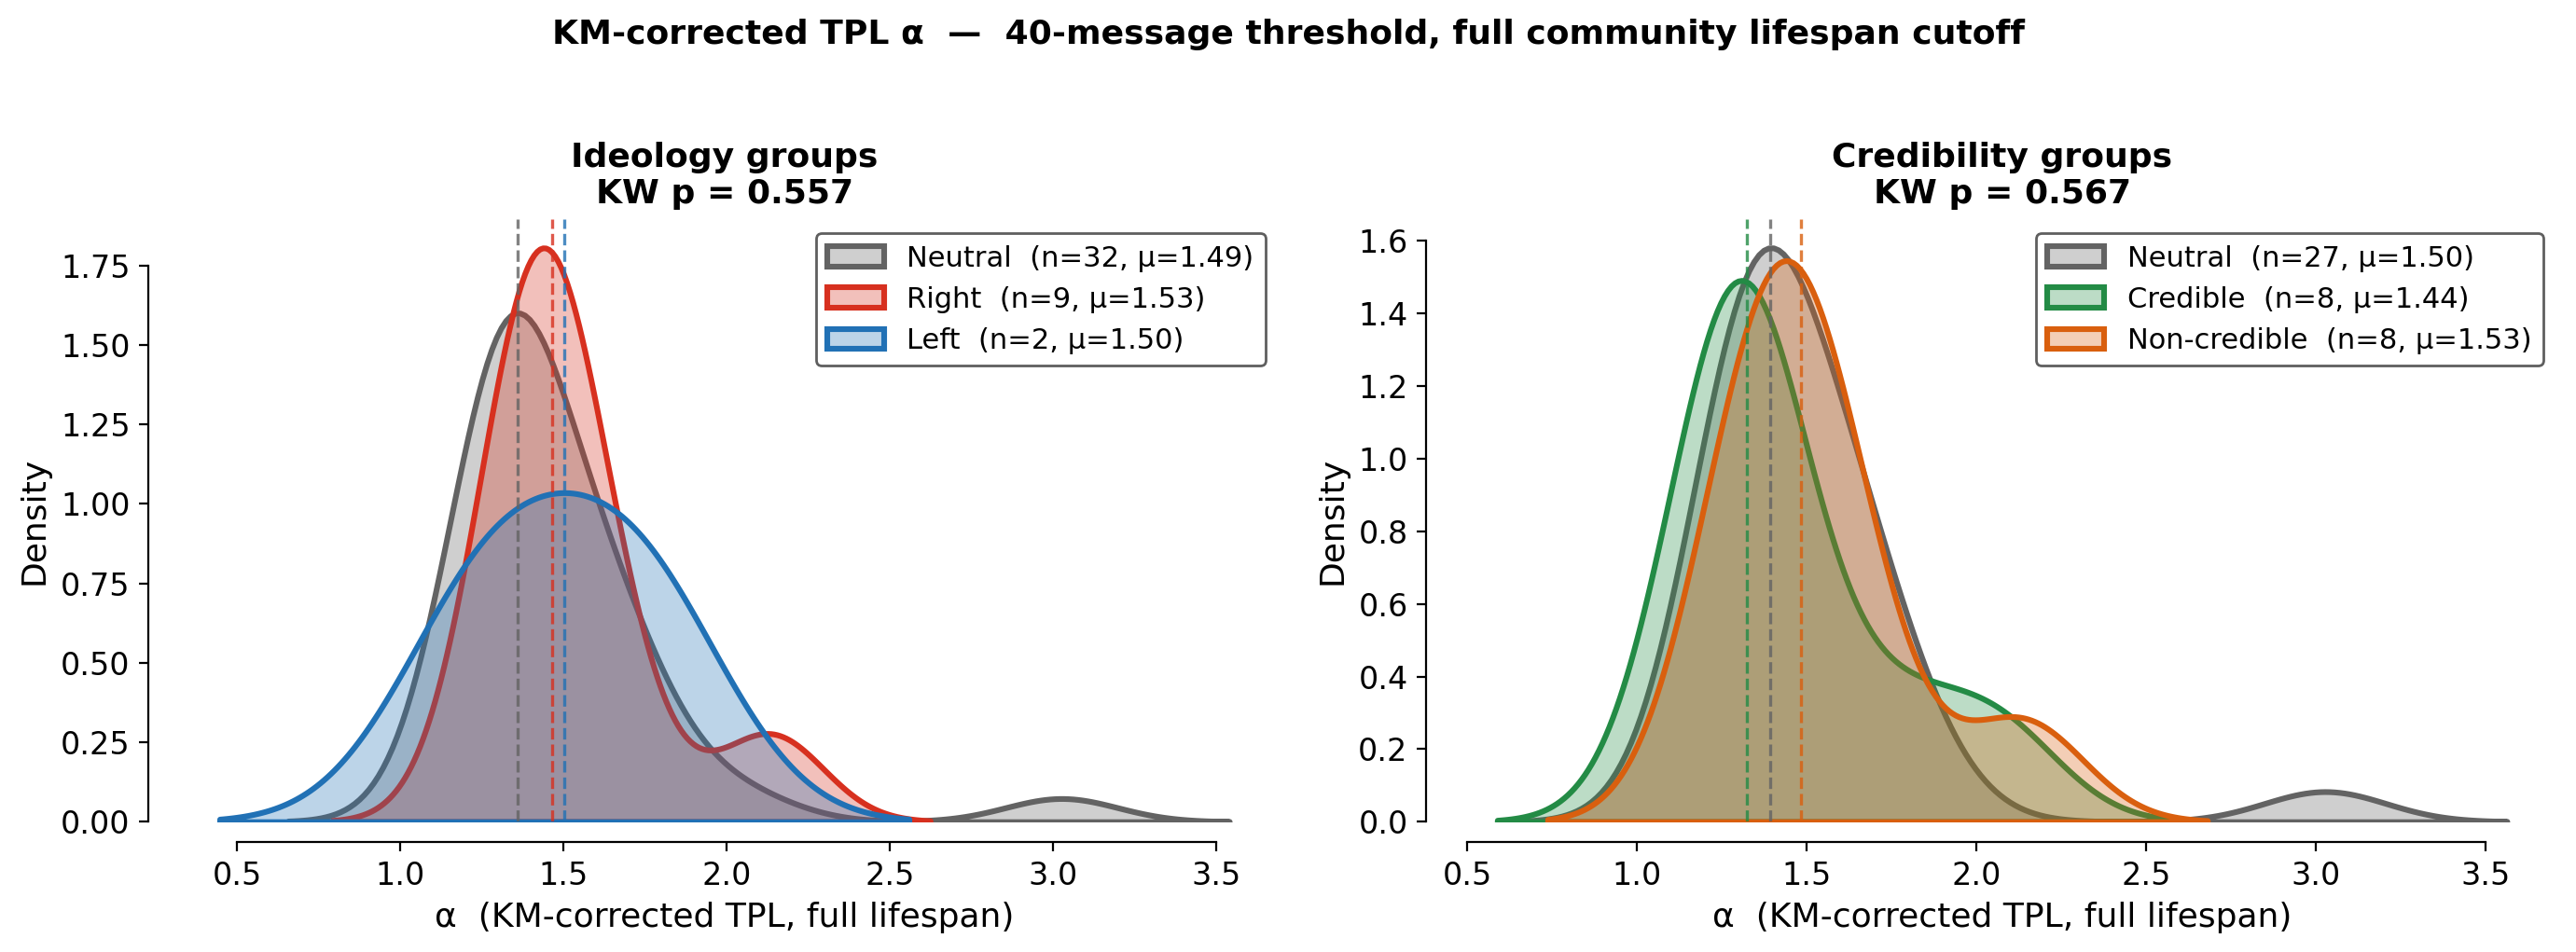

In [29]:
import matplotlib as mpl
from scipy.stats import kruskal

mpl.rcParams.update({'figure.dpi': 200, 'font.size': 13,
                     'axes.labelsize': 14, 'axes.titlesize': 13,
                     'legend.fontsize': 11, 'xtick.labelsize': 12,
                     'ytick.labelsize': 12})

# ── KS / Kruskal-Wallis tests ─────────────────────────────────────────────────
from scipy.stats import ks_2samp

# Ideology
kw_ideo = kruskal(alphas_neutral_km, alphas_right_km, alphas_left_km)
ks_nr   = ks_2samp(alphas_neutral_km, alphas_right_km)
ks_nl   = ks_2samp(alphas_neutral_km, alphas_left_km)
ks_rl   = ks_2samp(alphas_right_km,   alphas_left_km)
print("Ideology — Kruskal-Wallis: H={:.3f}, p={:.4f}".format(*kw_ideo))
print("  Neutral vs Right  : D={:.3f}, p={:.4f}".format(ks_nr.statistic, ks_nr.pvalue))
print("  Neutral vs Left   : D={:.3f}, p={:.4f}".format(ks_nl.statistic, ks_nl.pvalue))
print("  Right vs Left     : D={:.3f}, p={:.4f}".format(ks_rl.statistic, ks_rl.pvalue))

# Credibility
kw_cred = kruskal(alphas_neutral_cred_km, alphas_credible_km, alphas_non_credible_km)
ks_nc   = ks_2samp(alphas_neutral_cred_km, alphas_credible_km)
ks_nn   = ks_2samp(alphas_neutral_cred_km, alphas_non_credible_km)
ks_cn   = ks_2samp(alphas_credible_km,     alphas_non_credible_km)
print("\nCredibility — Kruskal-Wallis: H={:.3f}, p={:.4f}".format(*kw_cred))
print("  Neutral vs Credible      : D={:.3f}, p={:.4f}".format(ks_nc.statistic, ks_nc.pvalue))
print("  Neutral vs Non-credible  : D={:.3f}, p={:.4f}".format(ks_nn.statistic, ks_nn.pvalue))
print("  Credible vs Non-credible : D={:.3f}, p={:.4f}".format(ks_cn.statistic, ks_cn.pvalue))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=200)

# Palette
ideo_colors  = {'Neutral': '#636363', 'Right': '#d7301f', 'Left':  '#2171b5'}
cred_colors  = {'Neutral': '#636363', 'Credible': '#238b45', 'Non-credible': '#d95f0e'}

# ── Left: ideology ────────────────────────────────────────────────────────────
ax = axes[0]
for label, data, color in [
    ('Neutral',  alphas_neutral_km, ideo_colors['Neutral']),
    ('Right',    alphas_right_km,   ideo_colors['Right']),
    ('Left',     alphas_left_km,    ideo_colors['Left']),
]:
    if not data:
        continue
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.30,
                linewidth=2.2, bw_method='scott',
                label=f"{label}  (n={len(data)}, μ={np.mean(data):.2f})")
    ax.axvline(np.median(data), color=color, linewidth=1.2, linestyle='--', alpha=0.8)

p_str = f"KW p = {kw_ideo.pvalue:.3f}" if kw_ideo.pvalue >= 0.001 else f"KW p = {kw_ideo.pvalue:.2e}"
ax.set_title(f"Ideology groups\n{p_str}", weight='bold')
ax.set_xlabel("α  (KM-corrected TPL, full lifespan)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.legend(frameon=True, facecolor='white', edgecolor='0.3', framealpha=0.9)
sns.despine(ax=ax, trim=True, offset=8)

# ── Right: credibility ────────────────────────────────────────────────────────
ax = axes[1]
for label, data, color in [
    ('Neutral',       alphas_neutral_cred_km, cred_colors['Neutral']),
    ('Credible',      alphas_credible_km,     cred_colors['Credible']),
    ('Non-credible',  alphas_non_credible_km, cred_colors['Non-credible']),
]:
    if not data:
        continue
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.30,
                linewidth=2.2, bw_method='scott',
                label=f"{label}  (n={len(data)}, μ={np.mean(data):.2f})")
    ax.axvline(np.median(data), color=color, linewidth=1.2, linestyle='--', alpha=0.8)

p_str = f"KW p = {kw_cred.pvalue:.3f}" if kw_cred.pvalue >= 0.001 else f"KW p = {kw_cred.pvalue:.2e}"
ax.set_title(f"Credibility groups\n{p_str}", weight='bold')
ax.set_xlabel("α  (KM-corrected TPL, full lifespan)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.legend(frameon=True, facecolor='white', edgecolor='0.3', framealpha=0.9)
sns.despine(ax=ax, trim=True, offset=8)

fig.suptitle("KM-corrected TPL α  —  40-message threshold, full community lifespan cutoff",
             fontsize=13, weight='bold', y=1.02)
fig.tight_layout()
plt.show()


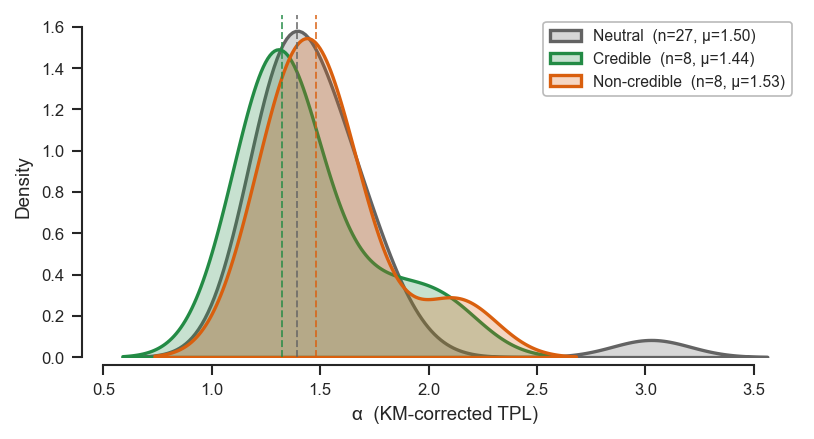

Saved paper_credibility_alpha_kde.pdf


In [32]:
# Paper-ready: credibility groups KDE only
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7.5, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

cred_colors = {
    'Neutral':      '#636363',
    'Credible':     '#238b45',
    'Non-credible': '#d95f0e',
}

fig, ax = plt.subplots(figsize=(5.5, 3.0))

for label, data, color in [
    ('Neutral',      alphas_neutral_cred_km, cred_colors['Neutral']),
    ('Credible',     alphas_credible_km,     cred_colors['Credible']),
    ('Non-credible', alphas_non_credible_km, cred_colors['Non-credible']),
]:
    if not data:
        continue
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.25,
                linewidth=1.6, bw_method='scott',
                label=f"{label}  (n={len(data)}, μ={np.mean(data):.2f})")
    ax.axvline(np.median(data), color=color, linewidth=0.9, linestyle='--', alpha=0.8)

#p_str = f"KW p = {kw_cred.pvalue:.3f}" if kw_cred.pvalue >= 0.001 else f"KW p = {kw_cred.pvalue:.2e}"
#ax.text(0.97, 0.97, p_str, transform=ax.transAxes,
#        fontsize=7.5, va='top', ha='right', color='0.3')

ax.set_xlabel("α  (KM-corrected TPL)")
ax.set_ylabel("Density")
#ax.set_title("Credibility groups", pad=6)
ax.legend(frameon=True, facecolor='white', edgecolor='0.7',
          framealpha=0.9, loc='upper right')
sns.despine(ax=ax, trim=True, offset=4)

fig.tight_layout()
fig.savefig('paper_credibility_alpha_kde.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved paper_credibility_alpha_kde.pdf')
